In [5]:
# Gerekli kütüphaneleri yüklüyoruz
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

# Gerekli paketleri yüklüyoruz
BiocManager::install(c("fgsea", "clusterProfiler", "org.Mm.eg.db", "biomaRt", "msigdbr"))

# Ekstra paketler
install.packages("tidyverse")


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.19 (BiocManager 1.30.25), R 4.4.1 (2024-06-14)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'fgsea' 'org.Mm.eg.db' 'biomaRt' 'msigdbr'”
Installing package(s) 'clusterProfiler'

Old packages: 'data.table', 'evaluate'

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [9]:
# Gerekli kütüphaneleri yüklüyoruz
library(biomaRt)
library(tidyverse)

# Ensembl fare veritabanına bağlanıyoruz
ensembl <- useMart("ensembl", dataset = "mmusculus_gene_ensembl")

# Count dosyasını yüklüyoruz (count verisi Ensembl ID ile)
count_data <- read.csv("/content/verdacount.csv", row.names = 1)

# Ensembl ID'leri elde ediyoruz
ensembl_ids <- rownames(count_data)

# Ensembl ID'lerini Entrez ID'lerine dönüştürme
conversion <- getBM(attributes = c('ensembl_gene_id', 'entrezgene_id'),
                    filters = 'ensembl_gene_id',
                    values = ensembl_ids,
                    mart = ensembl)

# Count datasındaki Ensembl ID'leri Entrez ID'lerle eşleştiriyoruz
count_data$entrezgene_id <- conversion$entrezgene_id[match(rownames(count_data), conversion$ensembl_gene_id)]

# Entrez ID'leri olmayanları (NA) temizliyoruz
count_data <- count_data[!is.na(count_data$entrezgene_id), ]

# Tekrarlayan (duplicate) Entrez ID'lerinin ortalamasını alarak birleştiriyoruz
count_data_clean <- count_data %>%
  group_by(entrezgene_id) %>%
  summarize(across(everything(), mean))

# Veriyi tekrar rownames olarak düzenliyoruz
rownames(count_data_clean) <- count_data_clean$entrezgene_id
count_data_clean <- count_data_clean[, -1]  # ID sütununu kaldırıyoruz

# Temizlenmiş veriyi CSV olarak kaydediyoruz
write.csv(count_data_clean, file = "/content/converted_count_data.csv")


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ dplyr::select()      masks biomaRt::select()
✖ purrr::transpose()   mas

In [10]:
# Tekrarlayan (duplicate) Entrez ID'lerinin ortalamasını alarak birleştiriyoruz
count_data_clean <- count_data %>%
  group_by(entrezgene_id) %>%
  summarize(across(everything(), mean))

# Tibble'ı data.frame'e çeviriyoruz
count_data_clean <- as.data.frame(count_data_clean)

# Veriyi tekrar rownames olarak düzenliyoruz (tibble yerine data.frame kullanarak)
rownames(count_data_clean) <- count_data_clean$entrezgene_id
count_data_clean <- count_data_clean[, -1]  # ID sütununu kaldırıyoruz

# Temizlenmiş veriyi CSV olarak kaydediyoruz
write.csv(count_data_clean, file = "/content/converted_count_data.csv")


In [ ]:
write.csv(count_data_clean, file = "/content/converted_count_data.csv")


In [ ]:
from google.colab import files
files.download('/content/converted_count_data.csv')


In [ ]:
# Gerekli kütüphaneleri yüklüyoruz
library(fgsea)
library(org.Mm.eg.db)
library(tidyverse)

# Dönüştürülmüş count dosyasını yüklüyoruz
count_data_clean <- read.csv("/content/converted_count_data.csv", row.names = 1)

# Gen listemizi (ortalama gen ekspresyonlarını) hazırlıyoruz
gene_list <- rowMeans(count_data_clean)

# Gen listemizi büyükten küçüğe sıralıyoruz
gene_list <- sort(gene_list, decreasing = TRUE)

# GO terimlerinden gene setleri oluşturuyoruz
library(msigdbr)
go_sets <- msigdbr(species = "Mus musculus", category = "C5") %>%
  split(x = .$entrez_gene, f = .$gs_name)


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: IRanges

Loading required package: S4Vectors


Att

In [ ]:
# GSEA analizini fgseaMultilevel ile yapıyoruz
fgsea_res <- fgsea(pathways = go_sets,
                   stats = gene_list,
                   minSize = 15,    # Minimum gen seti büyüklüğünü ayarlıyoruz
                   maxSize = 500)   # Maksimum gen seti büyüklüğünü ayarlıyoruz

# Sonuçları gösterelim
head(fgsea_res)


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (35.96% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 11 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”


pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>
GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS,0.2617383,0.4318553,0.07667469,0.7972096,1.0716274,17,"15926, 7...."
GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METABOLIC_PROCESS,0.6513487,0.7565852,0.03338270,0.7032944,0.9490801,19,"23971, 7...."
GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION,0.3466533,0.5054608,0.06266182,0.7684154,1.0329216,17,"12193, 2...."
GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,0.4095904,0.5591382,0.05479395,0.7491955,1.0131063,20,"56449, 7...."
GOBP_ACETYL_COA_BIOSYNTHETIC_PROCESS,0.3596404,0.5160565,0.06090393,0.7651173,1.0315996,18,"104112, ...."
GOBP_ACETYL_COA_METABOLIC_PROCESS,0.4285714,0.5757749,0.05269731,0.7287155,1.0038755,33,"104112, ...."


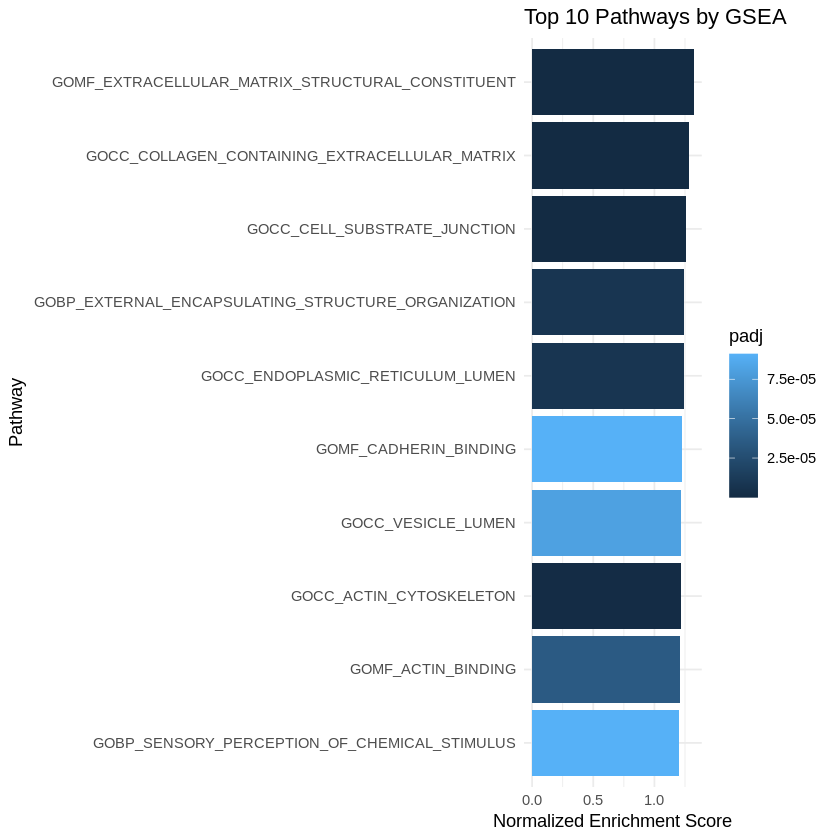

In [ ]:
# Barplot ile görselleştirme
topPathways <- fgsea_res[order(padj)][1:10, ]  # En anlamlı 10 yol
ggplot(topPathways, aes(reorder(pathway, NES), NES)) +
  geom_bar(stat="identity", aes(fill=padj)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Top 10 Pathways by GSEA") +
  theme_minimal()


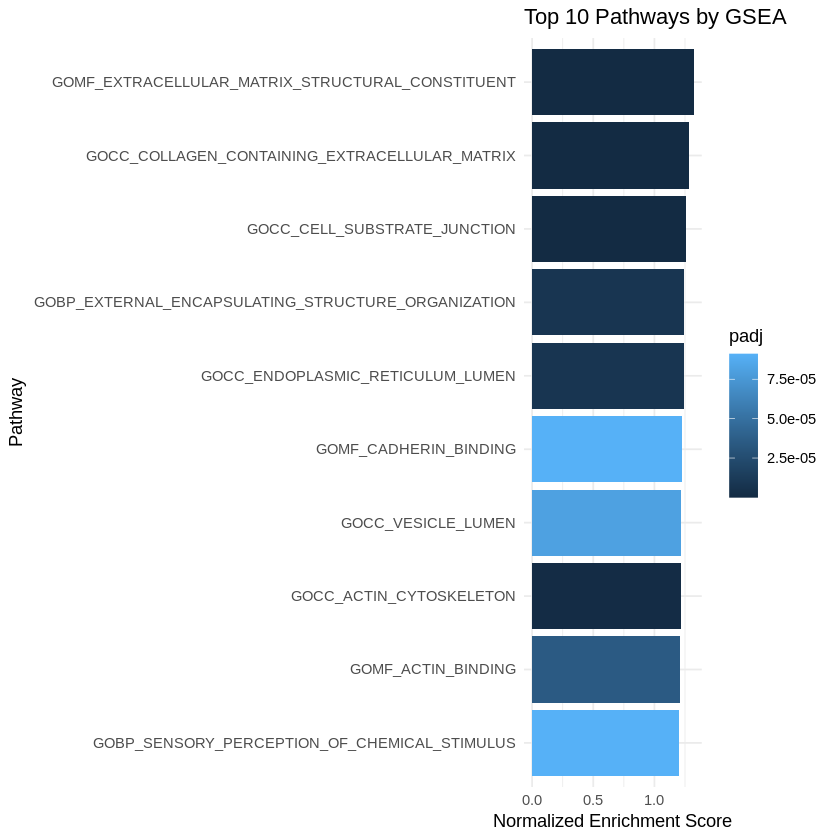

In [ ]:
# Gerekli kütüphaneleri yüklüyoruz
library(ggplot2)

# En önemli gen setlerini seçelim (padj'e göre)
topPathways <- fgsea_res[order(padj)][1:10, ]

# Barplot oluşturma
ggplot(topPathways, aes(reorder(pathway, NES), NES)) +
  geom_bar(stat="identity", aes(fill=padj)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Top 10 Pathways by GSEA") +
  theme_minimal()


Warning message in max(tops):
“no non-missing arguments to max; returning -Inf”
Warning message in min(bottoms):
“no non-missing arguments to min; returning Inf”
Warning message in max(tops):
“no non-missing arguments to max; returning -Inf”
Warning message in min(bottoms):
“no non-missing arguments to min; returning Inf”
Warning message in max(tops):
“no non-missing arguments to max; returning -Inf”
Warning message in min(bottoms):
“no non-missing arguments to min; returning Inf”


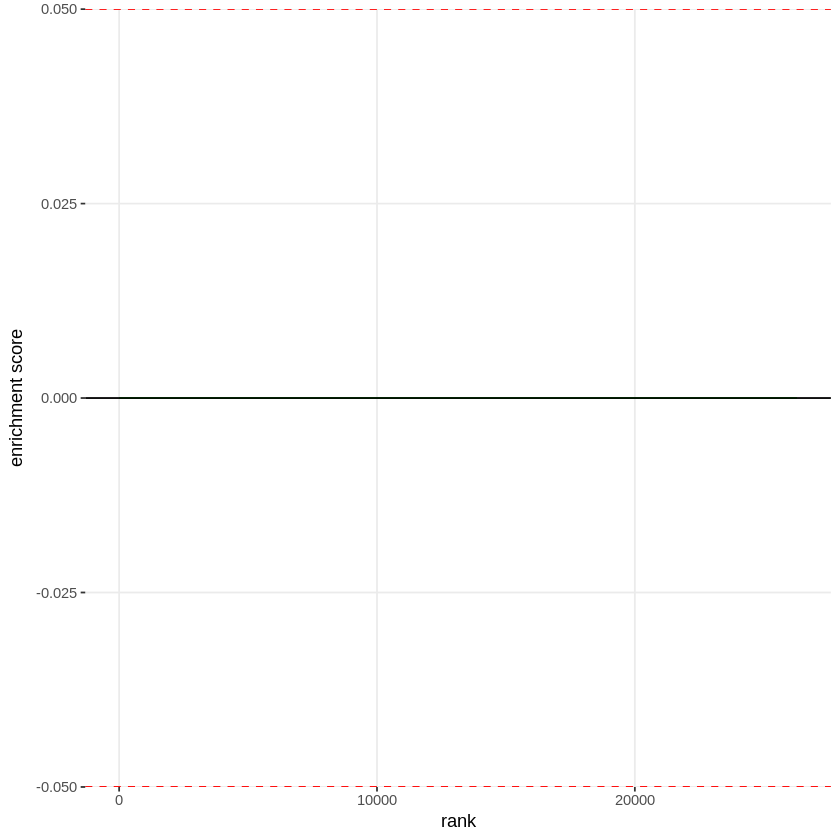

In [ ]:
# Örnek: Belirli bir pathway için enrichment plot
plotEnrichment(go_sets[["GO:0008150"]], gene_list)


In [ ]:
# Gerekli kütüphaneyi yüklüyoruz
library(data.table)

# Liste sütunları (örneğin, 'leadingEdge') içeren sütunları çıkarıyoruz
fgsea_res_table <- as.data.frame(fgsea_res)

# 'leadingEdge' sütununu kaldırıyoruz, çünkü bu bir liste içeriyor
fgsea_res_table$leadingEdge <- NULL

# Veriyi CSV olarak kaydediyoruz
write.csv(fgsea_res_table, file = "/content/gsea_results.csv", row.names = FALSE)


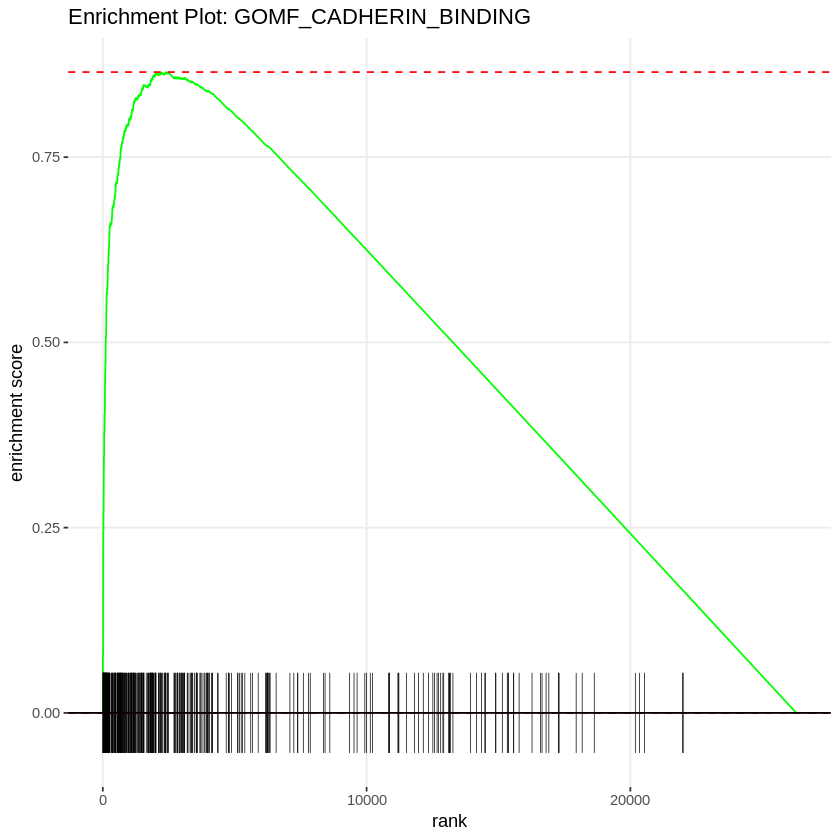

In [ ]:
# Gerekli kütüphaneleri yüklüyoruz
library(fgsea)
library(msigdbr)
library(ggplot2)

# GO terimlerinden gene setleri oluşturuyoruz
go_sets <- msigdbr(species = "Mus musculus", category = "C5") %>%
  split(x = .$entrez_gene, f = .$gs_name)

# İlgili gen setinin ismini kontrol ediyoruz
pathway_name <- "GOMF_CADHERIN_BINDING"

# İlgili yolağın GSEA enrichment plotunu oluşturuyoruz
if (pathway_name %in% names(go_sets)) {
  plotEnrichment(go_sets[[pathway_name]], gene_list) +
    ggtitle(paste("Enrichment Plot:", pathway_name))
} else {
  cat("Bu isimde bir yol bulunamadı:", pathway_name)
}


In [ ]:
# Mevcut gen setlerinin isimlerini kontrol etme
names(go_sets)


[1] "GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS"                                                                                                                                            
    [2] "GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS"                                                                                                                                                       
    [3] "GOBP_2FE_2S_CLUSTER_ASSEMBLY"                                                                                                                                                                
    [4] "GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_BIOSYNTHETIC_PROCESS"                                                                                                                               
    [5] "GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METABOLIC_PROCESS"                                                                                                                                  
    [6] "GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION"                                                                                                                                                    
    [7] "GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION"                                                                                                                                                      
    [8] "GOBP_5_PHOSPHORIBOSE_1_DIPHOSPHATE_METABOLIC_PROCESS"                                                                                                                                        
    [9] "GOBP_5S_CLASS_RRNA_TRANSCRIPTION_BY_RNA_POLYMERASE_III"                                                                                                                                      
   [10] "GOBP_ABSCISSION"                                                                                                                                                                             
   [11] "GOBP_ACETATE_ESTER_TRANSPORT"                                                                                                                                                                
   [12] "GOBP_ACETYL_COA_BIOSYNTHETIC_PROCESS"                                                                                                                                                        
   [13] "GOBP_ACETYL_COA_BIOSYNTHETIC_PROCESS_FROM_PYRUVATE"                                                                                                                                          
   [14] "GOBP_ACETYL_COA_METABOLIC_PROCESS"                                                                                                                                                           
   [15] "GOBP_ACETYLCHOLINE_METABOLIC_PROCESS"                                                                                                                                                        
   [16] "GOBP_ACID_SECRETION"                                                                                                                                                                         
   [17] "GOBP_ACIDIC_AMINO_ACID_TRANSPORT"                                                                                                                                                            
   [18] "GOBP_ACROSOMAL_VESICLE_EXOCYTOSIS"                                                                                                                                                           
   [19] "GOBP_ACROSOME_ASSEMBLY"                                                                                                                                                                      
   [20] "GOBP_ACROSOME_REACTION"                                                                                                                                                                      
   [21] "GOBP_ACTIN_CROS

In [6]:
# İlgili yolak ismi
pathway_name <- "GOMF_CADHERIN_BINDING"

# GSEA sonuçlarındaki ilgili yolağın zenginleşen genlerini almak
enriched_genes <- fgsea_res[fgsea_res$pathway == pathway_name, "leadingEdge"]

# Zenginleşen genlerin listesini gösterelim
if (length(enriched_genes) > 0) {
  enriched_genes <- unlist(enriched_genes)  # leadingEdge bir liste, bunu düzleştiriyoruz
  cat("Zenginleşen genler:\n")
  print(enriched_genes)
} else {
  cat("Belirtilen yolak için zenginleşen gen bulunamadı:", pathway_name)
}


ERROR: Error: object 'fgsea_res' not found


In [1]:
# Tüm yolaklar için zenginleşen genlerin listesini göstermek
fgsea_res$leadingEdge <- lapply(fgsea_res$leadingEdge, function(x) paste(x, collapse=", "))
head(fgsea_res[, c("pathway", "leadingEdge")])  # İlk birkaç yolu ve zenginleşen genlerini gösterelim


ERROR: Error: object 'fgsea_res' not found


In [3]:
# Gerekli kütüphaneler
library(data.table)

# Tüm yolaklar için zenginleşen genlerin listesini kaydetmek
# 'leadingEdge' sütununu düzleştiriyoruz, gen listelerini virgülle ayırıyoruz
fgsea_res$leadingEdge <- sapply(fgsea_res$leadingEdge, function(x) paste(x, collapse = ", "))

# fgsea sonuçlarını bir CSV dosyasına kaydediyoruz
write.csv(fgsea_res[, c("pathway", "padj", "NES", "leadingEdge")], file = "/content/gsea_leading_edge_genes.csv", row.names = FALSE)

cat("Tüm yolaklar ve zenginleşen genler '/content/gsea_leading_edge_genes.csv' dosyasına kaydedildi.\n")


ERROR: Error: object 'fgsea_res' not found


In [ ]:
from google.colab import files
files.download('/content/gsea_leading_edge_genes.csv')


In [ ]:
# Eğer dönüştürülmüş veriniz zaten varsa (örneğin count_data_clean adında)
# Önce veriyi kontrol edin
head(count_data_clean)

# Veriyi CSV olarak kaydediyoruz
write.csv(count_data_clean, file = "/content/converted_gene_ids.csv", row.names = TRUE)

cat("Dönüştürülmüş gene ID'leri '/content/converted_gene_ids.csv' dosyasına kaydedildi.\n")
